In [1]:
import pandas as pd

Author: Alana Pooler
<br>
Purpose: Complete Homework 9

# Homework 9
In this homework, we will be fitting and comparing three different models on a dataset using spark MLlib. 

## Dataset: Sleep Health

We will be the sleep health data set from Kaggle. It contains 100,000 synthetic patient records and includes demographic, lifestyle, sleep information, and conginitive scores. We will attempt to sleep disorder risk using the information provided in the data set. 

This data is synthetic to protect patient privacy, but all distributions, correlations, and occupation-specific profiles are calibrated against peer-reviewed sources. 

[View the data set on Kaggle.](https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset)

To get started, let's read in the data set.

In [2]:
df = pd.read_csv('sleep_health_dataset.csv')
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


The sleep disorder risk variable has four categories- healthy, mild, moderate, and severe. It is very imbalanced, with the majority of subjects in the 'healthy' category, and the least amount of subjects in the 'severe' category.

<AxesSubplot:xlabel='sleep_disorder_risk'>

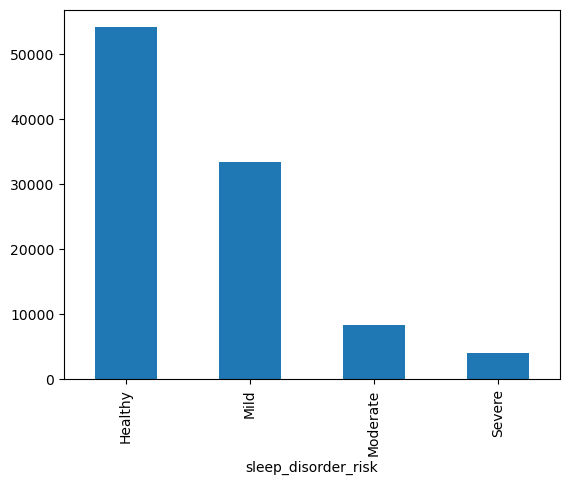

In [8]:
df['sleep_disorder_risk'].value_counts().plot(kind='bar')

To turn this variable into a binary variable and make it more balanced, let's reclassify the categories to 'healthy' and 'at risk'. For the purpose of modeling, we will encode healthy as 0 and at risk as 1. 

<AxesSubplot:xlabel='response'>

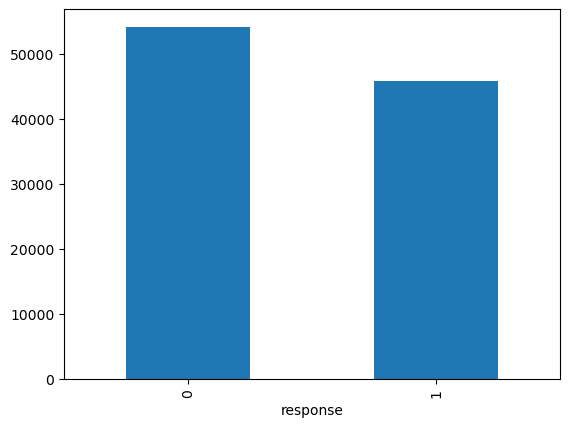

In [10]:
df['response'] = (df["sleep_disorder_risk"] != "Healthy").astype(int)
df['response'].value_counts().plot(kind='bar')